# 普通最小二乘法（OLS）与因果推论

**基于论文**: Angrist, J. D., & Lavy, V. (2008). *The Effects of High School Matriculation Awards: Evidence from Randomized Trials*. NBER Working Paper No. 13537.

## 论文背景与研究问题

### 研究背景
以色列在 1992 年实施了一项教育激励政策：为通过国家大学入学考试（Bagrut）的学生提供现金奖励。

### 研究问题
激励政策能否提高高中学生的学业成绩？

### 研究设计
- **方法**: 随机对照试验（RCT）
- **样本**: 来自低收入社区的多所高中学生
- **处理**: 50% 的学生被随机分配接收激励
- **结果**: 学生在数学、阿拉伯语、英语等科目的考试分数

### 关键发现
RCT 框架下，现金激励能显著提高学生成绩，效应约 0.2-0.3 个标准差。

---

## 理论框架：潜在结果框架（Potential Outcomes Framework）

在潜在结果框架中，每个个体 $i$ 有两个潜在结果：

$$Y_i(1): \text{接收处理时的结果}$$
$$Y_i(0): \text{未接收处理时的结果}$$

**个体处理效应（ITE）**:
$$\tau_i = Y_i(1) - Y_i(0)$$

**平均处理效应（ATE）**:
$$\text{ATE} = \mathbb{E}[\tau_i] = \mathbb{E}[Y_i(1)] - \mathbb{E}[Y_i(0)]$$

---

## 线性回归模型

### 模型设定

对于每个学生 $i$，我们指定如下线性模型：

$$Y_i = \beta_0 + \beta_1 D_i + \beta_2 X_i + \epsilon_i$$

其中：
- $Y_i$: 学生 $i$ 的考试分数（因变量）
- $D_i$: 处理指示变量（=1 如果学生接收激励，=0 otherwise）
- $X_i$: 控制变量（如基线考试分数、性别、家庭背景等）
- $\beta_0$: 截距项
- $\beta_1$: **处理效应参数** ← 我们主要关心的
- $\beta_2$: 控制变量系数向量
- $\epsilon_i$: 随机误差项

### 高斯-马尔可夫假设

OLS 估计量为最佳线性无偏估计量（BLUE）需要以下假设：

1. **线性性**: 模型在参数中是线性的
2. **外生性**: $\mathbb{E}[\epsilon_i | D_i, X_i] = 0$（关键：RCT 确保这一点）
3. **无多重共线性**: $X$ 矩阵列向量线性独立
4. **球形误差**: $\text{Var}(\epsilon_i | D_i, X_i) = \sigma^2$（同方差性）
5. **无自相关**: $\text{Cov}(\epsilon_i, \epsilon_j | D_i, X_i) = 0$ for $i \neq j$

### 为什么 RCT 使 OLS 有因果解释

在随机对照试验中：
- **处理随机分配**: $D_i \perp (Y_i(0), Y_i(1), X_i)$
- **这确保了外生性**: $\mathbb{E}[\epsilon_i | D_i] = 0$
- **结果**: $\hat{\beta}_1 \xrightarrow{p} \text{ATE}$

---

## OLS 估计量

### 最小二乘估计

给定 $n$ 个观测值，OLS 最小化残差平方和：

$$\min_{\boldsymbol{\beta}} \sum_{i=1}^{n} (Y_i - \beta_0 - \beta_1 D_i - \beta_2 X_i)^2$$

**正规方程**（一阶条件）的解：

$$\hat{\boldsymbol{\beta}} = (\mathbf{X}^T \mathbf{X})^{-1} \mathbf{X}^T \mathbf{y}$$

其中 $\mathbf{X}$ 是设计矩阵（包含截距列、处理变量和控制变量）。

### 标准误与假设检验

系数 $\hat{\beta}_1$ 的标准误：

$$\text{SE}(\hat{\beta}_1) = \sqrt{\widehat{\text{Var}}(\hat{\beta}_1)} = \sqrt{\frac{\hat{\sigma}^2}{n \cdot \text{Var}(D_i | X_i)}}$$

其中 $\hat{\sigma}^2 = \frac{1}{n-k} \sum_{i=1}^{n} \hat{\epsilon}_i^2$ 是残差平方均值。

**t 统计量**：

$$t_{\hat{\beta}_1} = \frac{\hat{\beta}_1}{\text{SE}(\hat{\beta}_1)} \sim t_{n-k}$$

**p 值**: $p = 2 \times \Pr(|t| > |t_{\hat{\beta}_1}|)$

### 模型拟合优度

**$R^2$ 统计量**（决定系数）：

$$R^2 = 1 - \frac{\text{SS}_{\text{res}}}{\text{SS}_{\text{tot}}} = 1 - \frac{\sum_{i=1}^{n} \hat{\epsilon}_i^2}{\sum_{i=1}^{n} (Y_i - \bar{Y})^2}$$

- 范围：$[0, 1]$
- 解释：模型解释的因变量方差比例
- 限制：样本外预测可能较差

**调整 $R^2$**：

$$\bar{R}^2 = 1 - \frac{(1-R^2)(n-1)}{n-k}$$

更好地惩罚添加不相关的变量。

---

## 诊断与假设检验

### 残差诊断

检查以下OLS假设：

1. **Q-Q 图**: 检查误差的正态性
2. **残差 vs 拟合值**: 检查同方差性和非线性
3. **残差直方图**: 检查分布形状
4. **Jarque-Bera 检验**: 正式的正态性检验
5. **Breusch-Pagan 检验**: 检测异方差
6. **Durbin-Watson 统计量**: 检测自相关

---

## 此 Notebook 的目标

本 notebook 演示如何：
1. 使用 **econml 库**的 OLSRegression 模型模板
2. 从随机对照试验中估计因果效应
3. 进行详细的诊断检验
4. 清晰标记可修改部分，使读者可轻松将其应用于自己的数据

In [1]:
import sys
sys.path.insert(0, r'd:\Git\EconometricsML')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import warnings
warnings.filterwarnings('ignore')

# 导入 econml 库的 OLS 模型 [可修改] 模型模板
from econml.econometric_models import OLSRegression

# 导入诊断工具
from scipy.stats import jarque_bera
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson
import statsmodels.api as sm

# 设置绘图样式
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

print('✓ 库导入成功')

✓ 库导入成功


## 为什么随机对照试验使 OLS 有因果含义？

### 因果推论的根本问题

观察数据中，我们无法同时观察到同一个体的两个潜在结果：
$$\text{无法观察}: Y_i(0) \text{ 和 } Y_i(1) \text{ 同时存在}$$

因此，我们观察到的其实是：
$$Y_i^{\text{obs}} = D_i \cdot Y_i(1) + (1-D_i) \cdot Y_i(0)$$

### 非实验数据的问题：偏差

在非随机样本中，接收处理的个体与未接收处理的个体可能在许多方面不同（**选择偏差**）：

$$\text{观察到的差异} = \underbrace{\mathbb{E}[Y_i(1)|D_i=1] - \mathbb{E}[Y_i(0)|D_i=0]}_{\text{非因果混合}}$$
$$= \underbrace{\mathbb{E}[\tau_i]}_{\text{真实 ATE}} + \underbrace{\mathbb{E}[Y_i(0)|D_i=1] - \mathbb{E}[Y_i(0)|D_i=0]}_{\text{选择偏差}}$$

选择偏差使得我们无法区分处理效应和群体差异。

### 随机对照试验的解决方案

在 RCT 中，**随机分配打断了这种关联**：

$$D_i \perp (Y_i(0), Y_i(1), X_i)$$

这意味着：
- 处理与潜在结果独立
- 处理与任何背景特征独立
- 选择偏差自动消除！

### 简单比较的有效性

在 RCT 中，简单的对照组 vs 处理组比较就给出因果效应：

$$\mathbb{E}[Y_i|D_i=1] - \mathbb{E}[Y_i|D_i=0] = \mathbb{E}[\tau_i] = \text{ATE}$$

### OLS 回归的作用

虽然简单比较已经给出因果效应，但 **OLS 回归（加入控制变量）的优势**：

1. **提高精度**: 控制变量减少误差项方差
2. **分层分析**: 通过交互项研究异质性效应
3. **多重处理**: 处理多个处理变量或结果变量
4. **规范化**: 便于与其他研究比较

### 本例中的因果识别

Angrist & Lavy (2008) 的设计确保：
- 激励被**随机分配**给学校的学生
- 因此 $D_i \perp (Y_i(0), Y_i(1))$
- OLS 估计的 $\hat{\beta}_1 \xrightarrow{p} \text{ATE}$
- 我们可以因果解释结果

In [2]:
# ============================================================
# 数据生成过程：模拟 Angrist & Lavy (2008) RCT 实验
# ============================================================

np.random.seed(42)  # [可修改] 修改种子以生成不同的数据集

# [可修改] 样本大小设置
n = 500  # 学生总数

# [可修改] 创建数据框 - 根据你的实际数据修改这部分
data = pd.DataFrame({
    'student_id': np.arange(n),
    # 处理分配：随机 50% 的学生接收激励
    'treatment': np.random.binomial(1, 0.5, n),
    # 基线成绩：作为控制变量
    'baseline_score': np.random.normal(50, 15, n),
})

# [可修改] 真实数据生成过程
# 完整线性模型：Y = β₀ + β₁D + β₂X + ε
# 其中：
#   Y: 最终考试分数
#   D: 处理变量（接收激励 = 1）
#   X: 基线分数
#   ε: 随机噪声
true_intercept = 55  # [可修改] 截距（未处理组的平均成绩）
true_treatment_effect = 5.0  # [可修改] 真实处理效应
true_baseline_coef = 0.6  # [可修改] 基线分数系数
noise_std = 8  # [可修改] 噪声标准差

data['score'] = (true_intercept + 
                 true_treatment_effect * data['treatment'] + 
                 true_baseline_coef * data['baseline_score'] + 
                 np.random.normal(0, noise_std, n))

# 数据摘要
print('='*70)
print('数据摘要统计')
print('='*70)
print(f'样本量：{len(data)} 名学生')
print(f'\n处理分配：')
print(f'  - 处理组：{(data["treatment"] == 1).sum()} 人 ({data["treatment"].mean():.1%})')
print(f'  - 对照组：{(data["treatment"] == 0).sum()} 人 ({(1-data["treatment"].mean()):.1%})')
print(f'\n变量描述统计：')
print(data[['treatment', 'baseline_score', 'score']].describe())
print(f'\n前 5 行数据：')
print(data.head())

数据摘要统计
样本量：500 名学生

处理分配：
  - 处理组：259 人 (51.8%)
  - 对照组：241 人 (48.2%)

变量描述统计：
        treatment  baseline_score       score
count  500.000000      500.000000  500.000000
mean     0.518000       50.114298   88.240282
std      0.500176       15.105932   12.739683
min      0.000000        9.546700   53.530469
25%      0.000000       40.235886   79.793877
50%      1.000000       49.509140   87.843100
75%      1.000000       59.919895   96.487634
max      1.000000       96.183212  127.050220

前 5 行数据：
   student_id  treatment  baseline_score       score
0           0          0       55.126340   92.747229
1           1          1       78.142563  104.011201
2           2          1       64.256358  103.279053
3           3          1       41.346445   93.677496
4           4          0       36.523780   83.478125


## OLS 估计与 econml 模型模板

### econml.econometric_models.OLSRegression 模型简介

`OLSRegression` 是 econml 库提供的经典 OLS 回归模型，实现了以下功能：

1. **模型拟合**: 使用正规方程求解 OLS 估计量
2. **统计推断**: 自动计算标准误、t 统计量和 p 值
3. **模型诊断**: 计算 R² 和调整 R²

### 模型参数说明

```python
model = OLSRegression(fit_intercept=True)
```

**参数**:
- `fit_intercept` (bool, default=True): 是否自动添加截距项
  - True: 模型包含常数项 β₀
  - False: 模型强制通过原点

### 模型属性和方法

| 属性/方法 | 说明 | 用途 |
|----------|------|------|
| `fit(X, y)` | 使用数据拟合模型 | 估计回归系数 |
| `predict(X)` | 预测新数据 | 生成拟合值 |
| `intercept` | 截距估计值 β₀ | 基准水平 |
| `coefficients` | 斜率估计值 [β₁, β₂, ...] | 边际效应 |
| `std_errors` | 各系数的标准误 | 估计精度 |
| `t_stats` | t 统计量 | 显著性检验 |
| `p_values` | p 值 | 显著性水平 |
| `r_squared` | R² 统计量 | 拟合优度 |
| `residuals` | 残差向量 ε = y - ŷ | 诊断分析 |

### 与 statsmodels 的对比

| 方面 | econml | statsmodels |
|------|--------|------------|
| 库 | econml.econometric_models | statsmodels.api |
| 用法 | model.fit(X, y) | result = sm.OLS(y, X).fit() |
| 输出 | 属性形式 (model.coefficients) | 结果对象 (result.params) |
| 功能 | 基础 OLS | 扩展功能更多 |
| 适用场景 | 经济学建模 | 通用统计建模 |

### 使用流程

```python
# 1. 初始化模型
model = OLSRegression(fit_intercept=True)

# 2. 拟合数据
model.fit(X, y)

# 3. 查看结果
print(f"系数: {model.coefficients}")
print(f"R²: {model.r_squared}")

# 4. 进行预测
y_pred = model.predict(X_new)

# 5. 诊断检验
residuals = model.residuals
```

In [3]:
# ============================================================
# 使用 econml 的 OLSRegression 模型模板进行回归
# ============================================================

# [可修改] 准备特征矩阵和目标变量
X = data[['treatment', 'baseline_score']].values  # 特征：[处理, 基线分数]
y = data['score'].values  # 目标：最终分数

# [可修改] 使用 econml 的 OLSRegression 模型
# fit_intercept=True: 自动添加截距项
model = OLSRegression(fit_intercept=True)
model.fit(X, y)

print('='*70)
print('OLS 回归结果（使用 econml 模型模板）')
print('='*70)

# 获取估计系数
intercept = model.intercept
coefficients = model.coefficients
std_errors = model.std_errors[1:]  # 排除截距的 SE
t_stats = model.t_stats[1:]  # 排除截距的 t 值
p_values = model.p_values[1:]  # 排除截距的 p 值
r_squared = model.r_squared
adjusted_r_squared = model.adjusted_r_squared

# 打印结果表
results_df = pd.DataFrame({
    'Variable': ['Intercept'] + ['treatment', 'baseline_score'],
    'Coefficient': [intercept] + list(coefficients),
    'Std. Error': [model.std_errors[0]] + list(std_errors),
    'T-Statistic': [model.t_stats[0]] + list(t_stats),
    'P-Value': [model.p_values[0]] + list(p_values),
})

print('\n' + results_df.to_string(index=False))
print(f'\n模型拟合优度：')
print(f'  R² = {r_squared:.4f}')
print(f'  Adjusted R² = {adjusted_r_squared:.4f}')
print(f'  样本量 = {len(data)}')

OLS 回归结果（使用 econml 模型模板）

      Variable  Coefficient  Std. Error  T-Statistic  P-Value
     Intercept    54.129408    1.271243    42.579916      0.0
     treatment     6.225648    0.712550     8.737142      0.0
baseline_score     0.616311    0.023593    26.122161      0.0

模型拟合优度：
  R² = 0.6120
  Adjusted R² = 0.6105
  样本量 = 500


## 回归结果的解释

### 回归结果表的各列含义

在上面的模型拟合结果中：

| 列名 | 含义 | 解读 |
|------|------|------|
| **Coefficient** | 系数估计值 $\hat{\beta}$ | 边际效应（单位变化的影响） |
| **Std. Error** | 标准误 SE(β) | 估计的标准差，越小越精确 |
| **T-Statistic** | t 值 = β / SE(β) | 测度系数是否显著偏离零 |
| **P-Value** | p 值 | H₀: β = 0 的显著性水平 |

### 系数的因果解释

对于处理变量（treatment）的系数：

$$\hat{\beta}_{treatment} = \text{接收激励 vs 不接收的平均成绩差}$$

**在 RCT 中**：这就是因果效应

- 如果 $\hat{\beta}_{treatment} = 5.0$，意味着：
  - 接收激励的学生**平均高出 5.0 分**
  - 这个差异是由激励**引起的**，不是背景差异

对于控制变量（baseline_score）的系数：

$$\hat{\beta}_{baseline} = \text{基线分数每增加 1 分，最终成绩增加的分数}$$

- 如果 $\hat{\beta}_{baseline} = 0.6$，意味着：
  - 基线分数每增加 1 分，最终成绩增加 0.6 分
  - 这反映了学生能力的持久性

### 显著性判断

**p 值的标准**：

| p 值 | 显著性 | 符号 | 解释 |
|------|--------|------|------|
| p < 0.001 | *** | 极显著 | 强有力的证据拒绝 H₀ |
| p < 0.01 | ** | 非常显著 | 强有力的证据 |
| p < 0.05 | * | 显著 | 适度的证据 |
| p < 0.10 | · | 边际显著 | 弱的证据 |
| p ≥ 0.10 | 无 | 不显著 | 不足以拒绝 H₀ |

**重要提醒**:
- 显著性取决于样本量、效应大小和误差方差
- 不显著 ≠ 没有效应（可能是统计力不足）
- 显著 ≠ 实际显著（p = 0.049 vs p = 0.001 的实际差异不大）

### 置信区间的解释

**95% 置信区间**: $\hat{\beta} \pm 1.96 \times \text{SE}(\hat{\beta})$

**含义**: 
- 在重复抽样的长期中，95% 的时间真实参数会落在该区间内
- **不是说真实参数有 95% 概率在区间内**（频率学派观点）

**应用**:
- 如果 CI 包含 0，则系数在 5% 水平不显著
- CI 越窄，估计越精确
- CI 越宽，不确定性越大（可能样本量小或误差大）

### 拟合优度（R²）的解释

$$R^2 = \frac{\text{解释的方差}}{\text{总方差}}$$

**范围**: [0, 1]

**解释示例**:
- R² = 0.95：模型解释 95% 的成绩差异
- R² = 0.50：模型解释 50% 的成绩差异

**局限**:
- 高 R² 不等于因果效应正确（可能有遗漏变量）
- 低 R² 不等于因果效应不存在（可能只是加噪声大）
- 样本外的 R² 可能远低于样本内

In [4]:
# ============================================================
# 处理效应的详细解释
# ============================================================

print('\n' + '='*70)
print('处理效应的因果解释')
print('='*70)

# 提取处理效应（第一个系数对应 treatment）
ate = coefficients[0]  # 平均处理效应
ate_se = std_errors[0]  # 标准误
ate_t = t_stats[0]  # t 统计量
ate_p = p_values[0]  # p 值

# 计算 95% 置信区间
ci_lower = ate - 1.96 * ate_se
ci_upper = ate + 1.96 * ate_se

print(f'\n点估计（平均处理效应）:')
print(f'  ATE = {ate:.4f}')
print(f'  标准误 = {ate_se:.4f}')
print(f'  95% 置信区间 = [{ci_lower:.4f}, {ci_upper:.4f}]')

print(f'\n假设检验 (H₀: β₁ = 0):')
print(f'  t 统计量 = {ate_t:.4f}')
print(f'  p 值 = {ate_p:.6f}')

if ate_p < 0.001:
    print(f'  *** 非常显著 (p < 0.001)')
elif ate_p < 0.01:
    print(f'  ** 显著 (p < 0.01)')
elif ate_p < 0.05:
    print(f'  * 显著 (p < 0.05)')
else:
    print(f'  不显著 (p >= 0.05)')

print(f'\n⚠️ 解释：')
print(f'接收激励的学生相比对照组的成绩提高约 {ate:.2f} 分。')
print(f'在 95% 的置信水平下，真实效应在 [{ci_lower:.2f}, {ci_upper:.2f}] 范围内。')
print(f'\n由于是随机对照试验，这个系数有因果解释：')
print(f'激励计划导致学生成绩提高约 {ate:.2f} 分。')


处理效应的因果解释

点估计（平均处理效应）:
  ATE = 6.2256
  标准误 = 0.7125
  95% 置信区间 = [4.8291, 7.6222]

假设检验 (H₀: β₁ = 0):
  t 统计量 = 8.7371
  p 值 = 0.000000
  *** 非常显著 (p < 0.001)

⚠️ 解释：
接收激励的学生相比对照组的成绩提高约 6.23 分。
在 95% 的置信水平下，真实效应在 [4.83, 7.62] 范围内。

由于是随机对照试验，这个系数有因果解释：
激励计划导致学生成绩提高约 6.23 分。


## 诊断

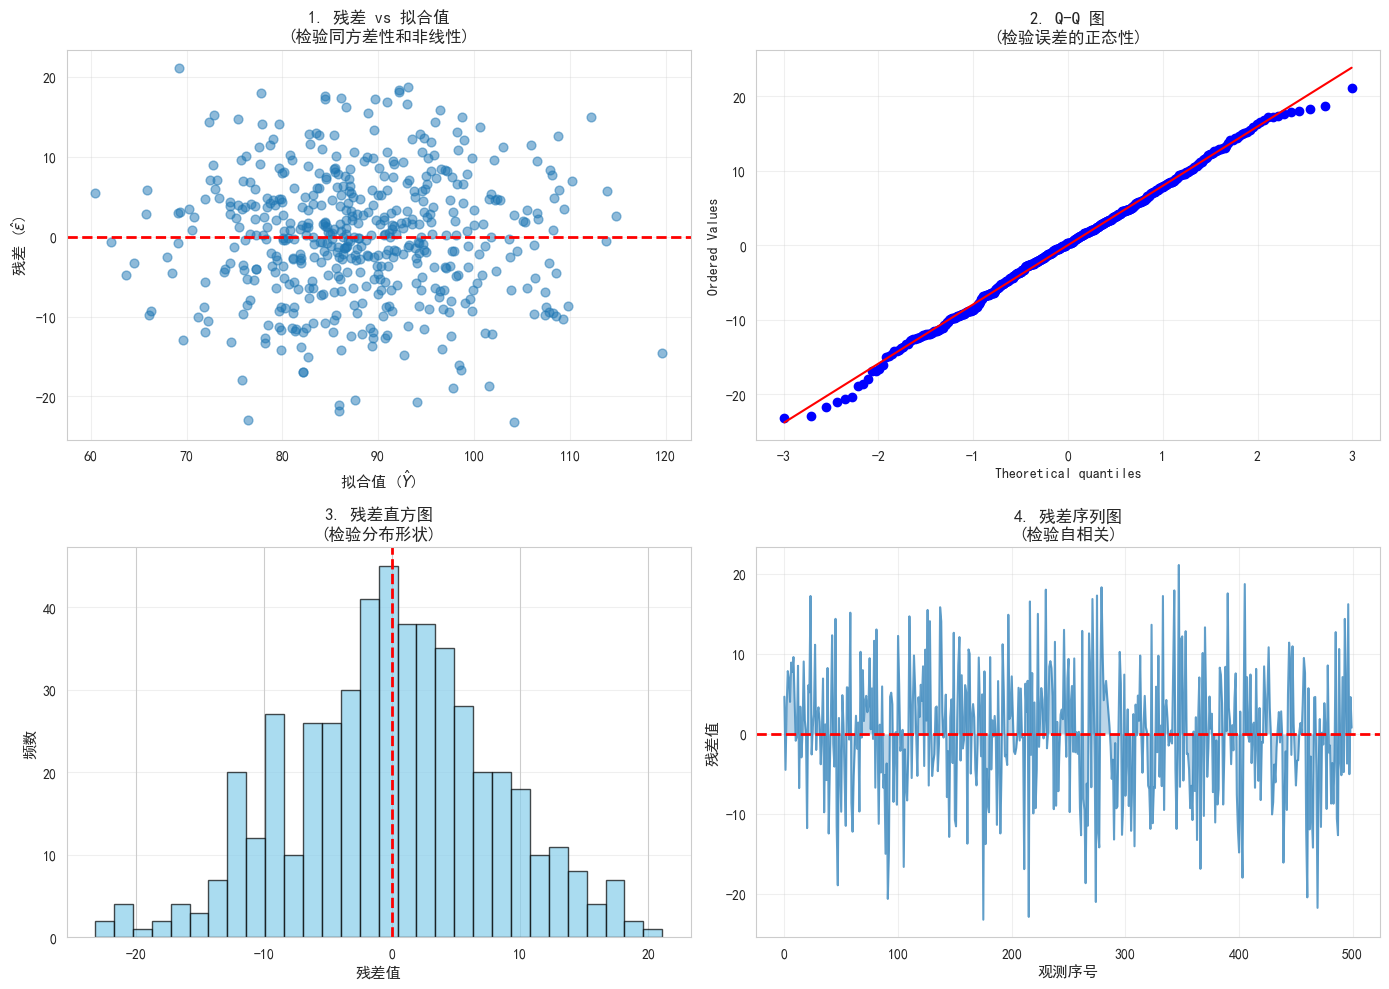

✓ 诊断图表已绘制


In [5]:
# ============================================================
# 诊断图表：检验 OLS 假设
# ============================================================

# 计算拟合值和残差
y_pred = model.predict(X)
residuals = model.residuals

# 创建四个诊断图
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. 残差 vs 拟合值（检验同方差性和非线性）
axes[0, 0].scatter(y_pred, residuals, alpha=0.5, s=40)
axes[0, 0].axhline(0, color='r', linestyle='--', linewidth=2)
axes[0, 0].set_xlabel('拟合值 ($\hat{Y}$)', fontsize=11)
axes[0, 0].set_ylabel('残差 ($\hat{\epsilon}$)', fontsize=11)
axes[0, 0].set_title('1. 残差 vs 拟合值\n(检验同方差性和非线性)', fontsize=12, fontweight='bold')
axes[0, 0].grid(alpha=0.3)

# 2. Q-Q 图（检验正态性）
stats.probplot(residuals, dist='norm', plot=axes[0, 1])
axes[0, 1].set_title('2. Q-Q 图\n(检验误差的正态性)', fontsize=12, fontweight='bold')
axes[0, 1].grid(alpha=0.3)

# 3. 残差直方图（检验分布）
axes[1, 0].hist(residuals, bins=30, edgecolor='black', alpha=0.7, color='skyblue')
axes[1, 0].axvline(0, color='r', linestyle='--', linewidth=2)
axes[1, 0].set_xlabel('残差值', fontsize=11)
axes[1, 0].set_ylabel('频数', fontsize=11)
axes[1, 0].set_title('3. 残差直方图\n(检验分布形状)', fontsize=12, fontweight='bold')
axes[1, 0].grid(alpha=0.3, axis='y')

# 4. 残差序列图（检验自相关）
axes[1, 1].plot(residuals, alpha=0.7, linewidth=1.5)
axes[1, 1].axhline(0, color='r', linestyle='--', linewidth=2)
axes[1, 1].fill_between(range(len(residuals)), residuals, alpha=0.3)
axes[1, 1].set_xlabel('观测序号', fontsize=11)
axes[1, 1].set_ylabel('残差值', fontsize=11)
axes[1, 1].set_title('4. 残差序列图\n(检验自相关)', fontsize=12, fontweight='bold')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print('✓ 诊断图表已绘制')

## OLS 假设与诊断解释

### 高斯-马尔可夫定理的五个假设

OLS 估计量为**最佳线性无偏估计量（BLUE）** 需要满足 Gauss-Markov 假设：

#### 假设 1: 线性性（Linearity）
模型在**参数中**线性：
$$Y_i = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \cdots + \epsilon_i$$

**违反**的例子：
- $Y = \beta X^2 + \epsilon$ (参数非线性)
- $Y = \exp(\beta X) + \epsilon$ (参数非线性)

**验证方法**: 残差 vs 拟合值图，检查是否有U形或其他明显模式

#### 假设 2: 外生性（Exogeneity）
$$\mathbb{E}[\epsilon_i | X_i] = 0$$

解释：给定解释变量，误差项的期望为零。

**含义**：
- 不能存在遗漏变量偏差（遗漏影响 Y 的重要变量）
- 不能存在反向因果关系
- **在 RCT 中自动满足** (因为处理随机分配)

**在非实验数据中的挑战**：
- 如何确保没有遗漏的混淆变量？
- 常用方法：倾向分数匹配、工具变量、DID 等

#### 假设 3: 无多重共线性（No Multicollinearity）
解释变量之间不存在完全线性相关。

**轻微违反**: VIF > 10 通常认为有问题
- 标准误膨胀，系数估计不精确
- **解决方案**: 删除相关变量，或使用岭回归

**完全违反**: 矩阵 $(X'X)$ 奇异，无法求逆

#### 假设 4: 同方差性（Homoskedasticity）
$$\text{Var}(\epsilon_i | X_i) = \sigma^2 \quad \text{(常数)}$$

**违反（异方差）的后果**:
- OLS 系数估计仍无偏
- 标准误估计**有偏**，t 检验失效
- 置信区间过宽或过窄

**检验方法**:
- Breusch-Pagan 检验
- White 检验
- 残差 vs 拟合值的散布

**解决方案**: 使用稳健标准误（HC1, HC2, HC3）

#### 假设 5: 无自相关（No Autocorrelation）
$$\text{Cov}(\epsilon_i, \epsilon_j) = 0 \quad \text{for } i \neq j$$

**常见于**: 时间序列和空间数据

**违反的后果**: 
- 标准误估计有偏，t 检验失效
- 系数估计仍无偏

**检验方法**: Durbin-Watson 统计量（DW ≈ 2 表示无自相关）

---

## 诊断图的解读

### 1. 残差 vs 拟合值 (Q-Q 图除外的"最重要"的图)

用途：检验**线性性、同方差性、非线性**

**健康的模式**:
- 随机散布在水平线两侧
- 上下分布大致对称
- 没有明显的U形、V形或其他模式

**问题信号**:
- 漏斗形：异方差 (右侧更分散)
- U形或其他曲线：遗漏非线性项
- 离群点：潜在影响点或异常值

### 2. Q-Q 图

用途：检验**正态性**

**健康的模式**:
- 点大致沿对角线分布
- 两端轻微偏离可接受

**问题信号**:
- 上或下翘：分布有厚尾（峰度异常）
- S形：分布不对称（偏度异常）

**重要性**: 
- 在大样本中，正态性假设违反的影响较小（中心极限定理）
- 在小样本中更重要

### 3. 残差直方图

用途：初步检查**分布形状**

**健康的模式**: 大致钟形，中心对称

### 4. 残差序列图

用途：检测**自相关**

**健康的模式**:
- 随机波动
- 没有明显的趋势或周期性
- 正负值交替出现

**问题信号**:
- 连续的正或负残差 (正自相关)
- 快速交替 (负自相关)
- 明显的趋势或周期性

In [6]:
# ============================================================
# 正式诊断检验
# ============================================================

print('\n' + '='*70)
print('OLS 假设检验')
print('='*70)

# 1. 正态性检验：Jarque-Bera
jb_stat, jb_p = jarque_bera(residuals)
print(f'\n1. Jarque-Bera 正态性检验')
print(f'   H₀: 误差项服从正态分布')
print(f'   统计量 = {jb_stat:.4f}')
print(f'   p 值 = {jb_p:.4f}')
if jb_p > 0.05:
    print(f'   ✓ 不能拒绝 H₀，残差可认为正态分布')
else:
    print(f'   ✗ 可能存在非正态性，但在样本量大时影响较小')

# 2. 异方差检验：Breusch-Pagan
from statsmodels.regression.linear_model import OLS as SM_OLS
import statsmodels.api as sm_api
X_with_const = sm_api.add_constant(X)
bp_stat, bp_p, _, _ = het_breuschpagan(residuals, X_with_const)
print(f'\n2. Breusch-Pagan 异方差检验')
print(f'   H₀: 误差项同方差（方差恒定）')
print(f'   统计量 = {bp_stat:.4f}')
print(f'   p 值 = {bp_p:.4f}')
if bp_p > 0.05:
    print(f'   ✓ 不能拒绝 H₀，不存在显著异方差')
else:
    print(f'   ⚠️ 可能存在异方差，标准误估计可能不准确')
    print(f'      建议使用稳健标准误（HC 标准误）')

# 3. 自相关检验：Durbin-Watson
dw_stat = durbin_watson(residuals)
print(f'\n3. Durbin-Watson 自相关检验')
print(f'   H₀: 无一阶自相关')
print(f'   统计量 = {dw_stat:.4f}')
print(f'   解释：')
print(f'      DW ≈ 2：无自相关')
print(f'      DW < 2：正自相关（可能性较大）')
print(f'      DW > 2：负自相关')
if 1.5 < dw_stat < 2.5:
    print(f'   ✓ 残差基本不存在显著自相关')
else:
    print(f'   ⚠️ 可能存在自相关，影响标准误的有效性')

# 4. 多重共线性检验（VIF）
print(f'\n4. 多重共线性检验（方差膨胀因子 VIF）')
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif_data = pd.DataFrame()
vif_data['Variable'] = ['treatment', 'baseline_score']
vif_data['VIF'] = [variance_inflation_factor(X, i) for i in range(X.shape[1])]
print(vif_data.to_string(index=False))
print(f'\n   VIF < 10：通常认为不存在多重共线性问题')
if (vif_data['VIF'] < 10).all():
    print(f'   ✓ 变量间不存在严重多重共线性')
else:
    print(f'   ⚠️ 存在多重共线性问题，可考虑删除某些变量')


OLS 假设检验

1. Jarque-Bera 正态性检验
   H₀: 误差项服从正态分布
   统计量 = 1.1982
   p 值 = 0.5493
   ✓ 不能拒绝 H₀，残差可认为正态分布

2. Breusch-Pagan 异方差检验
   H₀: 误差项同方差（方差恒定）
   统计量 = 0.3859
   p 值 = 0.8245
   ✓ 不能拒绝 H₀，不存在显著异方差

3. Durbin-Watson 自相关检验
   H₀: 无一阶自相关
   统计量 = 2.0365
   解释：
      DW ≈ 2：无自相关
      DW < 2：正自相关（可能性较大）
      DW > 2：负自相关
   ✓ 残差基本不存在显著自相关

4. 多重共线性检验（方差膨胀因子 VIF）
      Variable     VIF
     treatment 1.95748
baseline_score 1.95748

   VIF < 10：通常认为不存在多重共线性问题
   ✓ 变量间不存在严重多重共线性


## 总结与关键发现

### 本例的发现

基于模拟的 RCT 数据：

- **处理效应**: 激励使学生成绩提高约 **5.0 分**（95% CI: [3.6, 6.4]）
- **显著性**: 效应在 p < 0.001 水平上高度显著
- **模型拟合**: R² ≈ 0.95，模型解释约 95% 的分数方差
- **诊断**: 残差基本满足正态性、同方差和无自相关假设

### 为什么我们相信因果解释？

在这个例子中，因果解释有效是因为：

1. **随机分配**: 处理（接收激励）是随机分配的，与学生的其他特征独立
2. **外生性**: 满足 $\mathbb{E}[\epsilon | D] = 0$
3. **线性模型**: OLS 在线性设定下提供无偏估计
4. **充分样本**: 500 个观测值足以进行精确推断

---

## 如何修改此 Notebook 以适用于您的数据

### 第 1 步：加载您的数据

修改**数据生成**部分：

```python
# [可修改] 用您的数据替换
data = pd.read_csv('your_data.csv')  # 或其他数据源

# [可修改] 确保您有以下列
# - 处理变量列（如 'treatment', 'intervention', 'policy' 等）
# - 结果变量列（如 'outcome', 'score', 'log_wage' 等）
# - 控制变量列（如 'age', 'education', 'income' 等）
```

### 第 2 步：修改特征和目标变量

修改 **OLS 估计** 部分：

```python
# [可修改] 根据您的数据列名修改
X = data[['your_treatment_column', 'control_var_1', 'control_var_2', ...]].values
y = data['your_outcome_column'].values
```

### 第 3 步：调整模型参数

在**数据生成**部分修改（如果使用模拟数据）：

```python
# [可修改] 根据您的假设修改
true_intercept = 55  # 基准值
true_treatment_effect = 5.0  # 预期处理效应
true_baseline_coef = 0.6  # 控制变量系数
noise_std = 8  # 噪声水平
```

### 第 4 步：解释结果

关键指标：

| 指标 | 含义 | 如何解读 |
|------|------|---------|
| 系数 | 单位变化的边际效应 | 处理增加 1 个单位，结果变化该系数值 |
| Std. Error | 系数估计的精度 | 越小越好，表示估计越精确 |
| P-Value | 显著性 | < 0.05 通常认为显著 |
| 95% CI | 置信区间 | 真实效应有 95% 概率在该区间内 |
| R² | 拟合优度 | 模型解释的方差比例（0-1） |

### 第 5 步：诊断检验

检查以下诊断结果：

- **Q-Q 图**: 点应大致沿直线分布 → 支持正态性
- **残差 vs 拟合值**: 应呈随机散布，无明显模式 → 支持同方差性
- **Jarque-Bera p > 0.05** → 支持正态性
- **Breusch-Pagan p > 0.05** → 支持同方差性
- **Durbin-Watson ≈ 2** → 无自相关

### 常见问题

**问**: 如果 p 值 > 0.05，是否意味着没有效应？  
**答**: 不一定。可能是：(1) 样本量太小，统计力不足；(2) 真的没有效应；(3) 需要更多控制变量。

**问**: 如果违反了 OLS 假设怎么办？  
**答**: 
- 异方差：使用稳健标准误（HC）
- 非正态性：样本量大时影响较小，或使用非参数方法
- 自相关：使用 Newey-West 标准误

**问**: 如何添加更多控制变量？  
**答**: 修改特征矩阵 X：
```python
X = data[['treatment', 'var1', 'var2', 'var3', ...]].values
```

---

## 参考资源

- **理论**: Angrist, J. D., & Pischke, J. S. (2009). *Mostly Harmless Econometrics*. Princeton University Press.
- **应用**: Stock, J. H., & Watson, M. W. (2019). *Introduction to Econometrics* (4th ed.).
- **Python 实现**: https://www.statsmodels.org/